# GRU Recurrent Neural Network — Solution 1 to Problem 10.3

**TensorFlow architecture.** Train a GRU (Gated Recurrent Unit) network on the electric-load / temperature dataset and forecast electricity load one hour ahead.

Outputs: temperature series (Fig. 10.2), actuals-vs-predictions (Fig. 10.3), residual ACF (Fig. 10.4), and the prediction table with MAPE.

*Reproduced result: MAPE ≈ 0.0165 (book).*

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
import datetime as dt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import GRU, Dense, Input
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics import mean_absolute_percentage_error
from PythonTsa.TsTensor import tstensor, create_evaluation_df
from PythonTsa.plot_acf_pacf import acf_pacf_fig

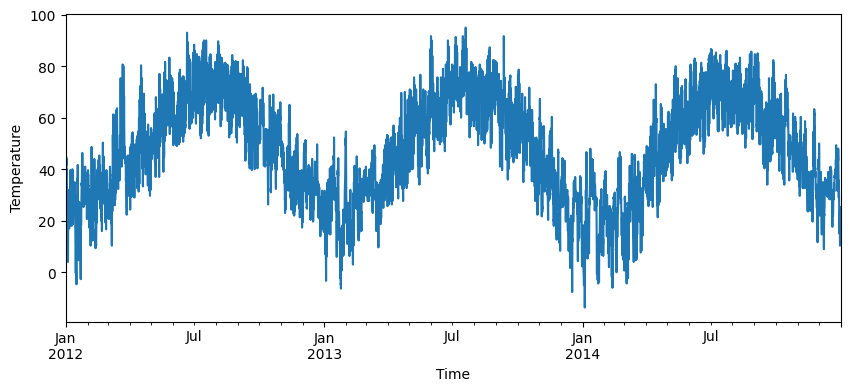

In [ ]:
tsdta = pd.read_csv('elec-temp.csv')
tsdta['time'] = pd.to_datetime(tsdta['time'])
tsdta.set_index('time', inplace=True)

tsdta['temp'].plot()
plt.xlabel('Time')
plt.ylabel('Temperature')
plt.savefig('gru_temperature.png', transparent=True, bbox_inches='tight')
plt.show()

In [ ]:
valid_stdta = '2014-09-01 00:00:00'
test_stdta = '2014-11-01 00:00:00'
train_mask = tsdta.index < valid_stdta
valid_mask = (tsdta.index >= valid_stdta) & (tsdta.index < test_stdta)
test_mask = tsdta.index >= test_stdta
train_dat = tsdta.copy()[train_mask]
valid_dat = tsdta.copy()[valid_mask]
test_dat = tsdta.copy()[test_mask]

T = 6
HORIZON = 1
y_scaler = MinMaxScaler(); y_scaler.fit(train_dat[['load']])
X_scaler = MinMaxScaler()
train_dat[['load', 'temp']] = X_scaler.fit_transform(train_dat)
tensor = {'X': (range(-T + 1, 1), ['load', 'temp'])}
train_inp = tstensor(dataset=train_dat, target='load', h=HORIZON,
                     tensor_structure=tensor, freq='h', drop_incomplete=True)
valid_dat[['load', 'temp']] = X_scaler.transform(valid_dat)
valid_inputs = tstensor(valid_dat, 'load', HORIZON, tensor)

In [ ]:
LATENT_DIM = 5
BATCH_SIZE = 32
EPOCHS = 40
model = Sequential()
model.add(Input(shape=(T, 2)))
model.add(GRU(LATENT_DIM))
model.add(Dense(HORIZON))
model.compile(optimizer='RMSprop', loss='mse')
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 gru (GRU)                   (None, 5)                 135       
 dense (Dense)               (None, 1)                 6         
Total params: 141 (564.00 B)


In [ ]:
earlystop = EarlyStopping(monitor='val_loss', min_delta=0, patience=5)
modelfit = model.fit(train_inp['X'], train_inp['target'],
    batch_size=BATCH_SIZE, epochs=EPOCHS,
    validation_data=(valid_inputs['X'], valid_inputs['target']),
    callbacks=[earlystop], verbose=1)

In [ ]:
test_dat[['load', 'temp']] = X_scaler.transform(test_dat)
test_inputs = tstensor(test_dat, 'load', HORIZON, tensor)
ts_predictions = model.predict(test_inputs['X'])
ev_tsdta = create_evaluation_df(ts_predictions, test_inputs, HORIZON, y_scaler)
print(ev_tsdta.head())
mape = mean_absolute_percentage_error(ev_tsdta['actual'], ev_tsdta['prediction'])
print('MAPE =', mape)

            timestamp    h   prediction  actual
0 2014-11-01 05:00:00  t+1  2724.787363  2714.0
1 2014-11-01 06:00:00  t+1  2993.897482  2970.0
2 2014-11-01 07:00:00  t+1  3251.675825  3189.0
3 2014-11-01 08:00:00  t+1  3391.187656  3356.0
4 2014-11-01 09:00:00  t+1  3526.012605  3436.0
MAPE = 0.02104150965342084


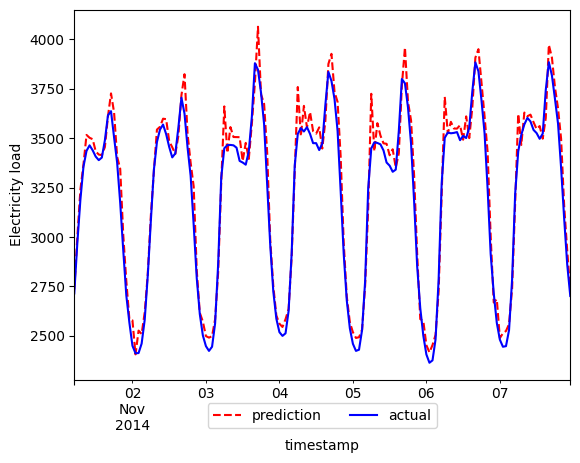

In [ ]:
ev_tsdta[ev_tsdta.timestamp < '2014-11-08'].plot(
    x='timestamp', y=['prediction', 'actual'], style=['--r', '-b'])
plt.ylabel('Electricity load')
plt.legend(loc='lower center', bbox_to_anchor=(0.5, -0.15), ncol=3)
plt.savefig('gru_actual_vs_pred.png', transparent=True, bbox_inches='tight')
plt.show()

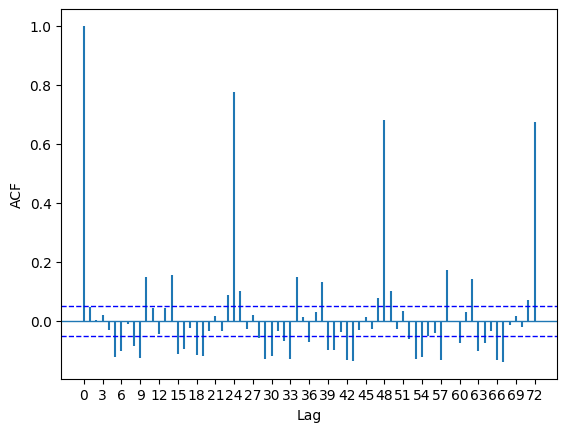

In [ ]:
resid = ev_tsdta['actual'] - ev_tsdta['prediction']
acf_pacf_fig(resid, lag=72)
plt.savefig('gru_residual_acf_pacf.png', transparent=True, bbox_inches='tight')
plt.show()